In [1]:
import json
import random
import unicodedata
from pathlib import Path
from collections import defaultdict

from tqdm import tqdm

import torch
from torch.utils.data import Dataset

import torchaudio
from torchaudio.prototype.transforms import ChromaSpectrogram

audio_dir = "/Users/jcastle/workspace/pansori/data/Audio"
label_json = "/Users/jcastle/workspace/pansori/data/label.json"


class AudioDataset(Dataset):
    def __init__(self, audio_dir, label_json, num_classes=4, sr=16000, channels='mono', window=20,):
        super().__init__()
        self.sr = sr
        self.window = window
        self.channels = channels
        self.num_classes = num_classes

        self.loaded_filename, self.loaded_audio = self.get_audio(audio_dir, ext='.wav')
        self.label_dict = self.get_label_dict(label_json)
        self.label_map = {'계면조': 1, '우조': 2, '평조': 3, 'Unknown':0, '아니리': 0, '창조': 0, '설렁제': 0}

    def get_audio(self, audio_dir, ext=".wav"):
        """
        지정된 디렉터리에서 특정 확장자의 오디오 파일을 로드
        Args:
            directory_path (str or Path): 오디오 파일이 있는 디렉터리 경로
            file_extension (str): 대상 확장자        
        Returns:
            dict: 파일명을 키로, 로드된 오디오 데이터를 값으로 하는 딕셔너리
        """
        audio_dir = Path(audio_dir)
        loaded_filename = []
        loaded_audio = {}
        for audio_file in tqdm(audio_dir.glob(f"*{ext}"), desc="Load Audio"):
            filename = "-".join(audio_file.name.split(".")[0].split("-")[1:])
            filename = unicodedata.normalize('NFC', filename)
            try:
                audio, sr = torchaudio.load(audio_file)
                if self.sr != sr:
                    audio = torchaudio.functional.resample(audio, orig_freq=sr, new_freq=self.sr)
                if self.channels == 'mono' and audio.shape[0] != 1:
                    audio = audio.mean(dim=0, keepdim=True)
                loaded_audio[filename] = audio
                loaded_filename.append(filename)
            except Exception as e: print(f"Error loading {audio_file.name}: {e}")
        return loaded_filename, loaded_audio

    def get_label_dict(self, label_json):
        """
        json 파일에서 filename, start, end, label 정보 추출
        Args: json_file_path: JSON 파일 경로        
        Returns: defaultdict: 파일명을 키로, [start, end, label] 리스트를 값으로 하는 defaultdict
        """
        label_dict = defaultdict(list)
        with open(label_json, 'r', encoding='utf-8') as file: label_data = json.load(file)

        for idx, item in enumerate(tqdm(label_data, desc='Load Label')): 
            filename = "-".join(item["file_upload"].split(".")[0].split("-")[1:])
            filename = unicodedata.normalize('NFC', filename)
            if filename not in self.loaded_filename: continue
            for annotation in item["annotations"]:
                for result in annotation["result"]:
                    start, end, label = result["value"]["start"], result["value"]["end"], result["value"]["labels"][0]
                    label_dict[filename].append({"start": start, "end": end, "label": label})
        return label_dict

    def get_label(self, filename, start):
        """
        window가 주어질 때, 초 단위로 비중을 계산하여 가장 비율이 높은 레이블로 labeling
        Args:
            filename (str): Audio filename
            start (float): Start time in seconds
        Returns:
            torch.Tensor: Tensor of shape [window, num_classes] with one-hot encoded labels per second
        """
        labels = torch.zeros((self.window, self.num_classes))
        label_ant = self.label_dict[filename]

        for sec_idx in range(self.window):
            start_sec = start + sec_idx
            end_sec = start_sec + 1
            
            overlap_ratios = {'Unknown': 1.0}
            
            for ant in label_ant:
                start_ant, end_ant = ant['start'], ant['end']
                label_name = ant['label']
                
                if end_ant <= start_sec or start_ant >= end_sec: continue

                overlap_start = max(start_sec, start_ant)
                overlap_end = min(end_sec, end_ant)
                overlap_duration = overlap_end - overlap_start
                
                if overlap_duration > 0:
                    if label_name not in overlap_ratios: overlap_ratios[label_name] = 0.0
                    
                    overlap_ratios[label_name] += overlap_duration
                    overlap_ratios['Unknown'] -= overlap_duration
            
            overlap_ratios['Unknown'] = max(0, overlap_ratios['Unknown'])
            max_label = max(overlap_ratios, key=overlap_ratios.get)
            
            if max_label == 'Unknown': labels[sec_idx, self.label_map['Unknown']] = 1
            else: labels[sec_idx, self.label_map[max_label]] = 1

        return labels

    def __len__(self):
        return len(self.loaded_audio)
    
    def __getitem__(self, idx):
        filename = self.loaded_filename[idx]
        audio, label = self.loaded_audio[filename], self.label_dict[filename]

        if self.window:
            start_sec = random.randint(0, int(audio.shape[1]/self.sr) - self.window)
            end_sec = start_sec + self.window
            audio = audio[:, start_sec * self.sr:end_sec * self.sr]
            label = self.get_label(filename, start_sec)
            return audio, label, (filename, start_sec)
        else:
            return audio, label

In [2]:
dset = AudioDataset(audio_dir=audio_dir, label_json=label_json)

Load Audio: 18it [00:06,  2.78it/s]
Load Label: 100%|██████████| 24/24 [00:00<00:00, 121281.08it/s]


torch.Size([1, 320000]) torch.Size([20, 4]) 03-박초월-수궁가_토끼_용왕_속이는_대목 160 180


(0.0, 3.0)

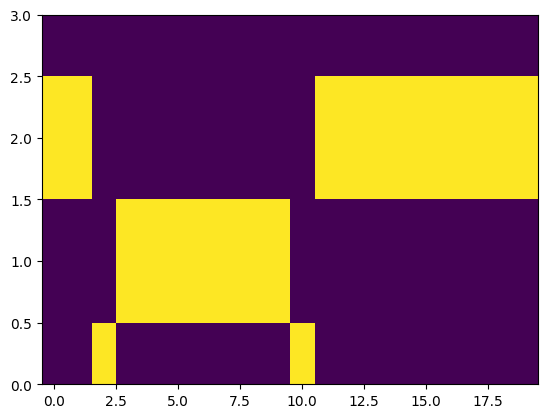

In [429]:
audio, label, meta = dset[1]
filename, start = meta
end = start+dset.window

print(audio.shape, label.shape, filename, start, end)

import matplotlib.pyplot as plt

plt.imshow(label.T, aspect='auto', origin='lower', interpolation='None')
plt.ylim(0,3)

In [431]:
l2 = 162.0192-162
l1 = 163-162.5453
l0 = 1-l1-l2

l2, l1, l0

(0.019200000000012096, 0.45470000000000255, 0.5260999999999854)

In [432]:
l2 = 170.4358-170
l1 = 171-170.9619
l0 = 1-l1-l2

l2, l1, l0

(0.4358000000000004, 0.03809999999998581, 0.5261000000000138)

In [430]:
dset.label_dict[filename]

[{'start': 0, 'end': 73.64511271415691, 'label': '아니리'},
 {'start': 73.64511271415691, 'end': 109.41559603246168, 'label': '계면조'},
 {'start': 109.94163255184851, 'end': 162.0192479711452, 'label': '우조'},
 {'start': 162.54528449053203, 'end': 170.43583228133454, 'label': '계면조'},
 {'start': 170.9618688007214, 'end': 215.14893642921552, 'label': '우조'},
 {'start': 215.67497294860235, 'end': 221.9874111812444, 'label': '계면조'},
 {'start': 222.51344770063122, 'end': 290.37215870153295, 'label': '우조'},
 {'start': 290.8981952209198, 'end': 307.2053273219116, 'label': '계면조'},
 {'start': 307.2053273219116, 'end': 352.44446798917943, 'label': '우조'},
 {'start': 352.97050450856625, 'end': 372.959892245266, 'label': '계면조'},
 {'start': 372.959892245266, 'end': 411.3605581605049, 'label': '우조'},
 {'start': 411.88659467989186, 'end': 426.61561722272313, 'label': '계면조'},
 {'start': 427.14165374211, 'end': 447.6570779981966, 'label': '우조'},
 {'start': 448.70915103697024, 'end': 513.411642921551, 'label': 

In [393]:
label

tensor([[0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.]])